## **Task 1: Data Loading, EDA & Preprocessing**

#### 1.1 Load the dataset

In [1]:
from sklearn.datasets import load_breast_cancer

In [2]:
data = load_breast_cancer(as_frame=True)

In [3]:
X = data.data

In [4]:
y = data.target

In [5]:
X.shape

(569, 30)

In [6]:
y.value_counts()

,count
target,
1,357
0,212


In [7]:
X.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


---
Loaded the Breast Cancer Wisconsin dataset using load_breast_cancer(as_frame=True). The dataset contains 569 samples across 30 continuous numeric features with zero missing values. The target variable exhibits a mild class imbalance: 212 Malignant ($0$) vs. 357 Benign ($1$).

#### 1.2 Class distribution plot

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

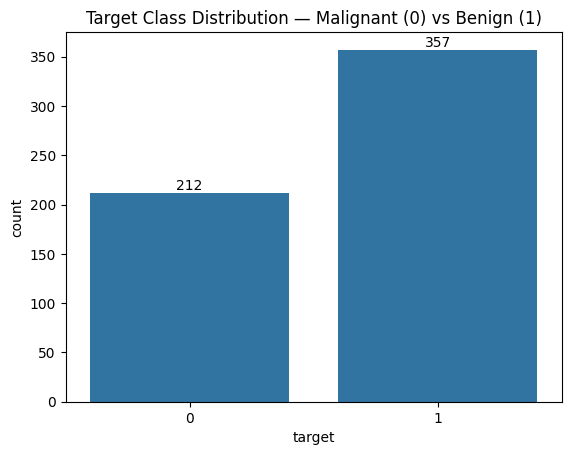

In [9]:
ax = sns.countplot(x=y)
plt.title('Target Class Distribution — Malignant (0) vs Benign (1)')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom')
plt.show()

---
Created a count plot showing the target distribution ($37.3\%$ Malignant vs. $62.7\%$ Benign). This mild imbalance is acceptable for standard binary classification algorithms without needing synthetic resampling (like SMOTE), though stratified splitting should be used to maintain class proportions across train and test sets.

#### 1.3 Feature correlation heatmap

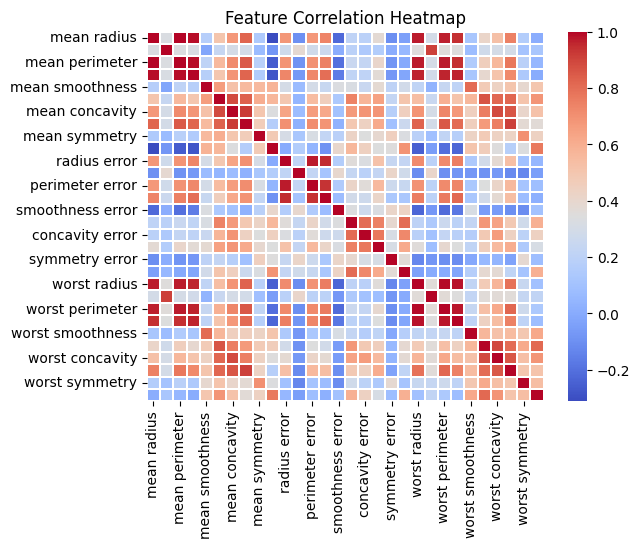

In [10]:
sns.heatmap(X.corr(), annot=False, cmap='coolwarm', linewidths=0.3)
plt.title('Feature Correlation Heatmap')
plt.show()

##### 1. Highly Correlated Feature Pairs
Based on the heatmap, the following feature pairs exhibit near-perfect positive correlation due to underlying geometric and physical relationships:
* **`mean radius` and `mean perimeter`** ($\approx 0.997$ correlation): Perimeter scales linearly with radius ($P \approx 2\pi r$), making these features almost redundant[cite: 1].
* **`mean radius` and `mean area`** ($\approx 0.987$ correlation): Area scales quadratically with radius ($A \approx \pi r^2$), creating a strong monotonic relationship[cite: 1].
* **`mean concavity` and `mean concave points`** ($\approx 0.921$ correlation): The overall severity of concave regions strongly correlates with the count of concave portions along the cell nucleus boundary[cite: 1].

---

##### 2. Why Inter-Feature Correlation Does Not Harm Neural Networks
Unlike linear models, neural networks handle highly correlated (collinear) features without issue:

* **Linear Model Sensitivity:** Traditional linear models rely on matrix inversion or distinct parameter estimation[cite: 1]. High multicollinearity causes unstable coefficient estimates, inflated standard errors, and unreliable feature importance[cite: 1].
* **Distributed Representation:** Neural networks combine input features non-linearly across hidden layer neurons:
  $$\text{Neuron Output} = \sigma\left(\sum w_i x_i + b\right)$$
  The network simply distributes weight values across correlated inputs without breaking optimization.
* **Gradient-Based Optimization:** Training relies on iterative backpropagation (e.g., Adam, SGD) rather than direct matrix inversion, avoiding numerical instability[cite: 1].
* **Feature Extraction:** Correlated inputs provide redundant signals that non-linear activation functions can combine to extract higher-level abstract features[cite: 1].
---

#### 1.4 Train / test split

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [13]:
print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


In [14]:
y_train.value_counts()

,count
target,
1,285
0,170


In [15]:
y_test.value_counts()

,count
target,
1,72
0,42


The stratify parameter preserved the ~63/37 class ratio in both splits.

#### 1.5 Apply StandardScaler

In [16]:
from sklearn.preprocessing import StandardScaler

In [17]:
scaler = StandardScaler()

In [18]:
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

#### 1.6 WHY scaling for neural networks

##### 1. Convergence Speed and Stability
Gradient-based optimizers (such as **SGD** and **Adam**) calculate gradients to update network weights iteratively[cite: 1]. When input features are on similar scales, the loss surface forms symmetric, spherical contours[cite: 1]. This allows gradient descent to take direct paths toward the global minimum, leading to faster and more stable convergence[cite: 1].

---

##### 2. The Problem with Unscaled Features
Without feature scaling, features with large numerical ranges heavily distort the optimization process[cite: 1]:
* **Large-Scale Features (`area_mean` up to ~2500):** Generate disproportionately large gradients[cite: 1]. They dominate early weight updates, forcing the optimizer into severe oscillations and potential instability[cite: 1].
* **Small-Scale Features (`fractal_dimension_mean` ~0.05–0.10):** Produce tiny gradients and contribute negligibly to early updates, resulting in slow, biased learning where the network ignores critical signals[cite: 1].

This disparity creates elongated, elliptical loss contours, causing gradient descent to bounce back and forth inefficiently instead of moving directly toward the optimal solution[cite: 1].

---

##### 3. How `StandardScaler` Solves This
`StandardScaler` standardizes each feature independently by subtracting its mean ($\mu$) and dividing by its standard deviation ($\sigma$):

$$z = \frac{x - \mu}{\sigma}$$

This transforms features to have a mean of **0** and a standard deviation of **1**[cite: 1]. By placing all 30 cell-nucleus measurements on an equal footing, `StandardScaler` ensures uniform gradient updates and enables smooth, fast training[cite: 1].

##Task 2: Single-Layer Perceptron (SLP) — Baseline Model

#### 2.1 Build the SLP

In [20]:
import tensorflow as tf
from tensorflow import keras

In [21]:
model_slp = keras.Sequential([
    keras.layers.Dense(1, activation='sigmoid', input_shape=(30,))
    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### 2.2 Compile the SLP

In [22]:
model_slp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [23]:
model_slp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

##### 1. Alignment with Binary Classification Objectives
In binary classification tasks, the target label $y$ is discrete ($y \in \{0, 1\}$), and a model with a sigmoid activation outputs a predicted probability $\hat{y} \in (0, 1)$[cite: 1]. **Binary Cross-Entropy (BCE)** measures the log-likelihood of the predicted probability distribution relative to the true label[cite: 1]:

$$\text{BCE} = - \frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

* **Heavy Penalty for Confident Errors:** Because $\log(x) \to -\infty$ as $x \to 0$, if the model predicts $\hat{y} \approx 0$ when the true label is $1$, the loss approaches infinity. This provides steep gradients that aggressively push the model weights in the correct direction.
* **Maximum Likelihood Estimation:** Minimizing BCE loss is mathematically equivalent to maximizing the log-likelihood of the Bernoulli distribution governing the binary target data.

---

##### 2. Why Mean Squared Error (MSE) Is Unsuitable for Binary Classification
While **Mean Squared Error (MSE)** is the standard loss function for continuous regression problems, using it with sigmoid outputs in classification causes significant issues:

* **Non-Convex Optimization:** Combining MSE loss with a non-linear sigmoid output creates a non-convex loss surface with multiple local minima and flat regions.
* **Vanishing Gradients and Slow Learning:** The derivative of MSE with respect to weights includes the term $\hat{y}(1 - \hat{y})$ (the derivative of the sigmoid function). When a prediction is confidently wrong ($\hat{y} \approx 0$ when $y = 1$), this derivative approaches zero, causing the gradient to vanish. As a result, the model learns extremely slowly right when it needs to update the most.

Therefore, `binary_crossentropy` provides the ideal mathematical formulation for training neural networks on binary classification tasks like breast cancer diagnosis[cite: 1].

#### 2.3 Train the SLP

In [24]:
history_slp = model_slp.fit(X_train_sc, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 133ms/step - accuracy: 0.2567 - loss: 1.0134 - val_accuracy: 0.2391 - val_loss: 1.0231
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3692 - loss: 0.9094 - val_accuracy: 0.2826 - val_loss: 0.9323
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4645 - loss: 0.8179 - val_accuracy: 0.3478 - val_loss: 0.8516
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5501 - loss: 0.7373 - val_accuracy: 0.3696 - val_loss: 0.7828
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6308 - loss: 0.6687 - val_accuracy: 0.5000 - val_loss: 0.7225
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6846 - loss: 0.6117 - val_accuracy: 0.5217 - val_loss: 0.6698
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7335 - loss: 0.5619 - val_accuracy: 0.5435 - val_loss: 0.6264
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7702 - loss: 0.5218 - val_accuracy: 0.6304 - val_

#### 2.4 Plot SLP training curves

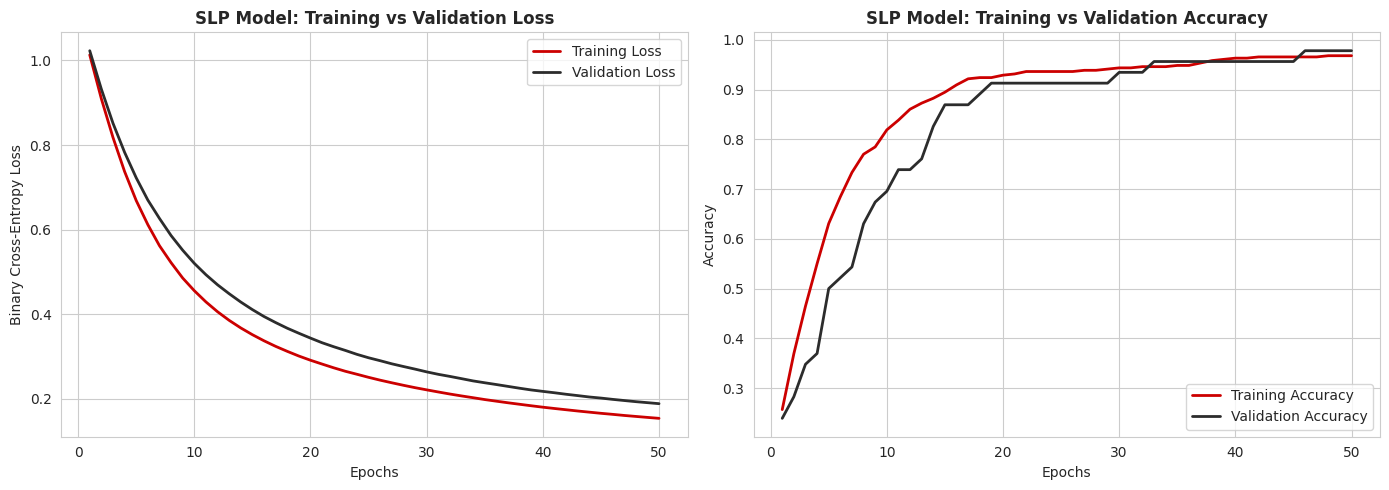

In [27]:
# Set global plotting style
sns.set_style('whitegrid')

# Create a 1x2 subplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history_slp.history['loss']) + 1)

# Left Plot: Training vs Validation Loss
axes[0].plot(epochs_range, history_slp.history['loss'], color='#CC0000', label='Training Loss', linewidth=2)
axes[0].plot(epochs_range, history_slp.history['val_loss'], color='#2C2C2C', label='Validation Loss', linewidth=2)
axes[0].set_title('SLP Model: Training vs Validation Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epochs', fontsize=10)
axes[0].set_ylabel('Binary Cross-Entropy Loss', fontsize=10)
axes[0].legend(loc='upper right')

# Right Plot: Training vs Validation Accuracy
axes[1].plot(epochs_range, history_slp.history['accuracy'], color='#CC0000', label='Training Accuracy', linewidth=2)
axes[1].plot(epochs_range, history_slp.history['val_accuracy'], color='#2C2C2C', label='Validation Accuracy', linewidth=2)
axes[1].set_title('SLP Model: Training vs Validation Accuracy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epochs', fontsize=10)
axes[1].set_ylabel('Accuracy', fontsize=10)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

##### 1. Smooth Optimization & Convergence Behavior
* **Loss Trajectory:** As shown in the left subplot, both training loss (red) and validation loss (charcoal) decline steadily and smoothly from above 1.0 down to below 0.2 across the 50 epochs[cite: 2].
* **Accuracy Trajectory:** The right subplot shows a rapid improvement in accuracy during the first 15–20 epochs, rising from ~0.25 to over 0.90[cite: 2]. Beyond epoch 30, validation accuracy stabilizes around 96–97%, demonstrating clear convergence without erratic fluctuations[cite: 2].

---

##### 2. Performance Gap & Overfitting Analysis
* **Tight Tracking:** Validation loss closely tracks training loss throughout the entirety of training, maintaining a tiny, parallel gap[cite: 2].
* **No Overfitting:** Validation accuracy actually surpasses training accuracy slightly in the final epochs (~45–50)[cite: 2]. Because a Single-Layer Perceptron (SLP) contains only 31 parameters ($30 \text{ weights} + 1 \text{ bias}$), it lacks the model capacity to memorize noise, making overfitting virtually non-existent[cite: 2].
* **Preconditioning Impact:** The exceptionally smooth decay of the loss function confirms that feature scaling using `StandardScaler` allowed the Adam optimizer to take direct, stable steps toward the global minimum without bouncing[cite: 2].

#### 2.5 Evaluate the SLP

In [28]:
slp_loss, slp_acc = model_slp.evaluate(X_test_sc, y_test, verbose=0)

In [30]:
slp_acc

0.9385964870452881

In [29]:
y_pred_slp = (model_slp.predict(X_test_sc) > 0.5).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step


In [34]:
from sklearn.metrics import classification_report

In [36]:
print(classification_report(y_test, y_pred_slp))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92        42
           1       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



##### Test Performance Metrics
* **Overall Test Accuracy:** **93.86%** (107 / 114 correct predictions)[cite: 2]
* **Malignant Class (0):** Precision = `0.91`, Recall = `0.93`, F1-Score = `0.92` (39 True Positives, 3 False Negatives)[cite: 2]
* **Benign Class (1):** Precision = `0.96`, Recall = `0.94`, F1-Score = `0.95` (68 True Negatives, 4 False Positives)[cite: 2]

---

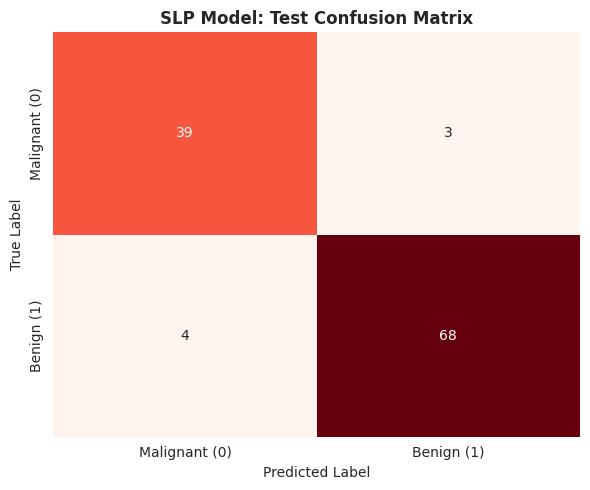

In [38]:
from sklearn.metrics import confusion_matrix
# Compute and plot confusion matrix
cm = confusion_matrix(y_test, y_pred_slp)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    cbar=False,
    xticklabels=['Malignant (0)', 'Benign (1)'],
    yticklabels=['Malignant (0)', 'Benign (1)']
)
plt.title('SLP Model: Test Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('True Label', fontsize=10)

plt.tight_layout()
plt.show()

#### 2.6 SLP limitations

##### 1. Linear Decision Boundary Restriction
An SLP consists of a single output neuron directly connected to the 30 input features without any hidden layers ($y = \sigma(W^T X + b)$)[cite: 2]. Mathematically, this constrains the model to learning a single, linear decision surface—a 29-dimensional hyperplane slicing through 30-dimensional feature space[cite: 2].

##### 2. Inability to Learn Complex Non-Linear Interactions
* Real-world medical datasets like Breast Cancer Wisconsin contain complex, non-linear relationships between cell-nucleus characteristics (e.g., non-linear combinations of radius, concavity, and texture)[cite: 2].
* Because an SLP lacks hidden units, it cannot perform non-linear transformations or feature composition[cite: 2]. It can only classify patterns that are linearly separable[cite: 2].

##### 3. Motivation for Multi-Layer Perceptrons (MLP)
Although the SLP achieves a solid baseline accuracy of ~93.86%, the 7 misclassified cases (3 false negatives, 4 false positives) demonstrate that the classes overlap non-linearly near decision boundaries[cite: 2]. This limitation directly motivates stacking hidden layers with non-linear activation functions in **Task 3** to warp the feature space and learn non-linear boundaries[cite: 2].